In [1]:
#upload file
from google.colab import files
uploaded = files.upload()

Saving Heart_Disease_Detection.csv to Heart_Disease_Detection.csv


In [2]:
# import python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [ ]:
#Load the csv file and display data
import pandas as pd
# Load the CSV file into a Pandas DataFrame
data = pd.read_csv('Heart_Disease_Detection.csv')

# Display basic information about the data
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Gender          918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
#count of column and rows
data.shape

(918, 12)

In [ ]:
#check for null values (identified values,avoid errors)
pd.isnull(data).sum()

,0
Age,0
Gender,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
data.columns

Index(['Age', 'Gender', 'ChestPainType', 'RestingBP', 'Cholesterol',
       'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak',
       'ST_Slope', 'HeartDisease'],
      dtype='object')

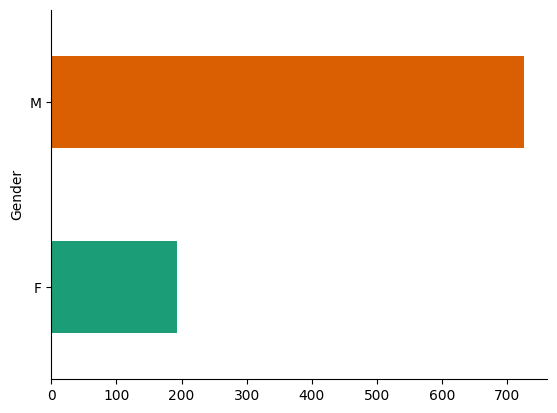

In [ ]:
#What is the count of male and female in the dataset?
from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

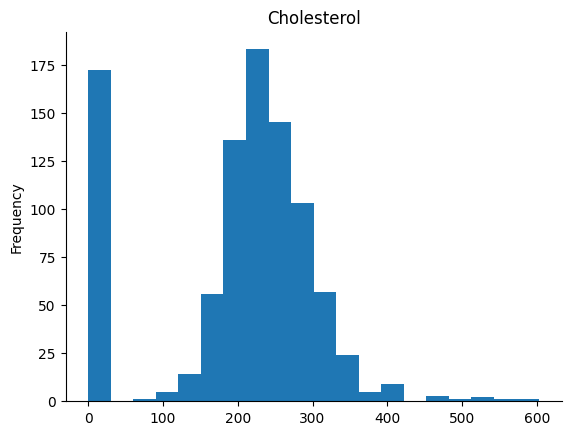

In [ ]:
#cholesterol
from matplotlib import pyplot as plt
data['Cholesterol'].plot(kind='hist', bins=20, title='Cholesterol')
plt.gca().spines[['top', 'right',]].set_visible(False)

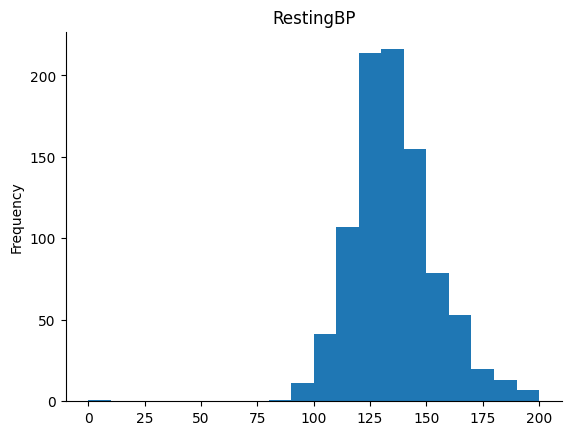

In [ ]:
# Resting Bp

from matplotlib import pyplot as plt
data['RestingBP'].plot(kind='hist', bins=20, title='RestingBP')
plt.gca().spines[['top', 'right',]].set_visible(False)

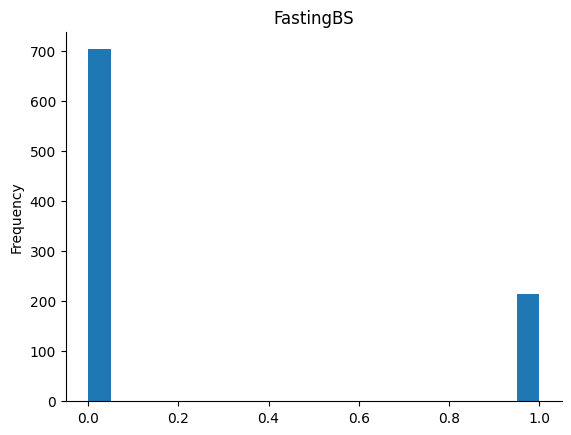

In [ ]:
#FastingBS

from matplotlib import pyplot as plt
data['FastingBS'].plot(kind='hist', bins=20, title='FastingBS')
plt.gca().spines[['top', 'right',]].set_visible(False)

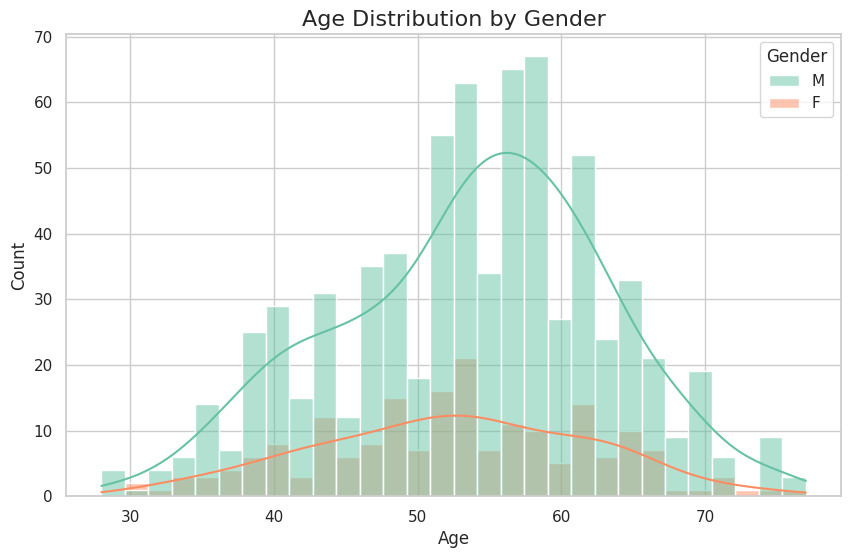

In [ ]:
##What is the distribution of age and gender in the dataset?
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style for the plots
sns.set(style="whitegrid")
#Distribution of Age and Gender
#This plot shows the age distribution for different genders. It helps identify trends in age demographics.
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="Age", hue="Gender", kde=True, palette="Set2", bins=30)
plt.title("Age Distribution by Gender", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()


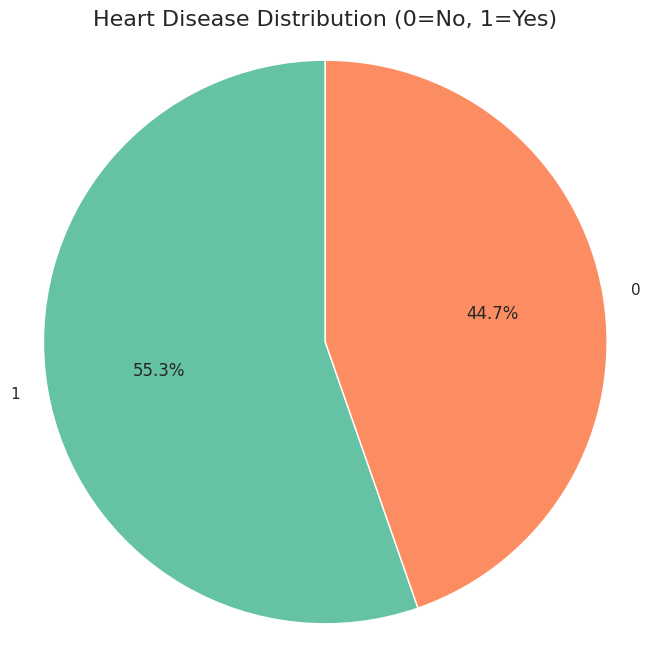

In [ ]:
##What is the percentage of heart disease distribution among the dataset?
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style="whitegrid")

#Pie chart of Heart Disease distribution
heart_disease_counts = data['HeartDisease'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(heart_disease_counts, labels=heart_disease_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2", 2))
plt.title("Heart Disease Distribution (0=No, 1=Yes)", fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()


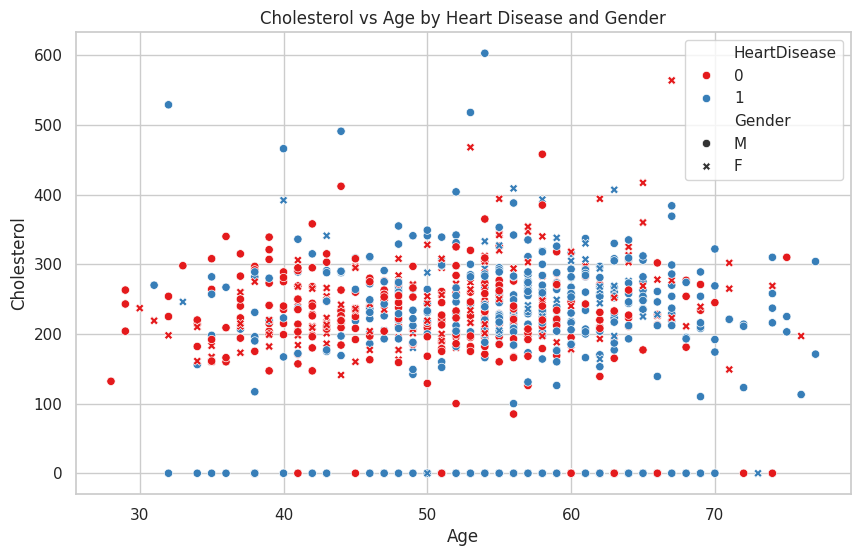

In [ ]:
#How cholesterol and age are corelate in heart disease and gender?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Cholesterol', hue='HeartDisease', style='Gender', data=data, palette='Set1')
plt.title('Cholesterol vs Age by Heart Disease and Gender')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

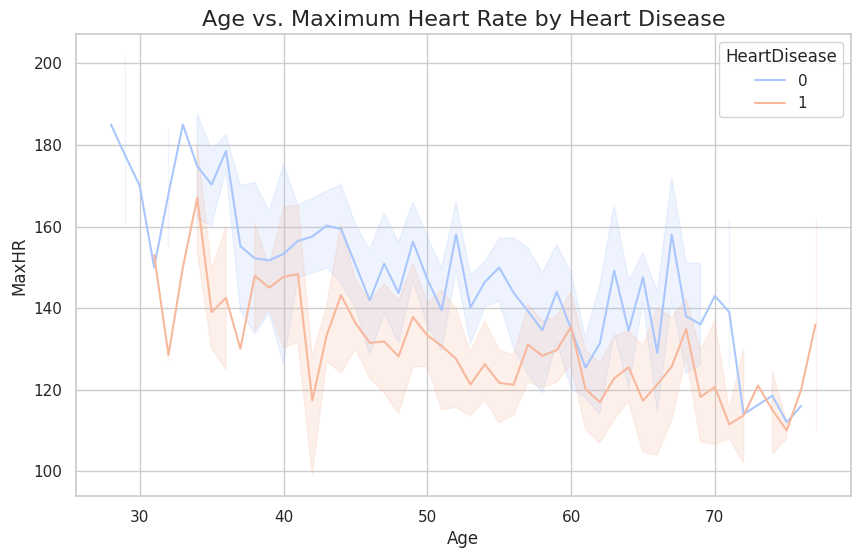

In [ ]:
#How Maximum Heart Rate relate with Age
# This line chart shows the trend of maximum heart rate across different ages, separated by heart disease presence.
plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x="Age", y="MaxHR", hue="HeartDisease", palette="coolwarm")
plt.title("Age vs. Maximum Heart Rate by Heart Disease", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("MaxHR", fontsize=12)
plt.show()

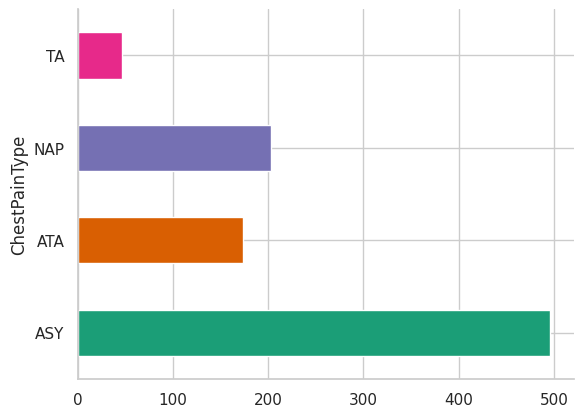

In [ ]:
##How does chest pain type correlate with heart disease?
#ATA (Angina Type A): Chest pain due to reduced blood flow to the heart, usually triggered by activity or stress.
#NAP (Non-Anginal Pain): Chest pain not related to heart problems, often caused by issues like reflux or muscle strain.
#ASY (Asymptomatic): No chest pain despite potential underlying heart conditions.
#"TA" refers to typical angina, which is chest discomfort caused by reduced blood flow to the heart, often triggered by physical exertion or stress.
from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('ChestPainType').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)


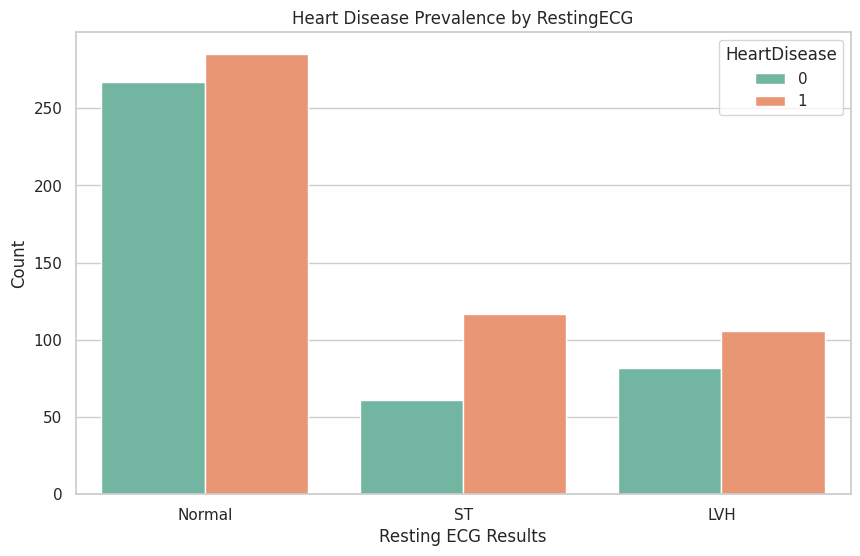

In [ ]:
#How Heart Disease Prevalence by RestingECG?
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(x='RestingECG', hue='HeartDisease', data=data, palette='Set2', hue_order=[0, 1])
plt.title('Heart Disease Prevalence by RestingECG')
plt.xlabel('Resting ECG Results')
plt.ylabel('Count')
plt.show()

<ipython-input-10-ae5d6a806eff>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x="FastingBS", y="Cholesterol", hue="HeartDisease", ci=None, palette="cubehelix")


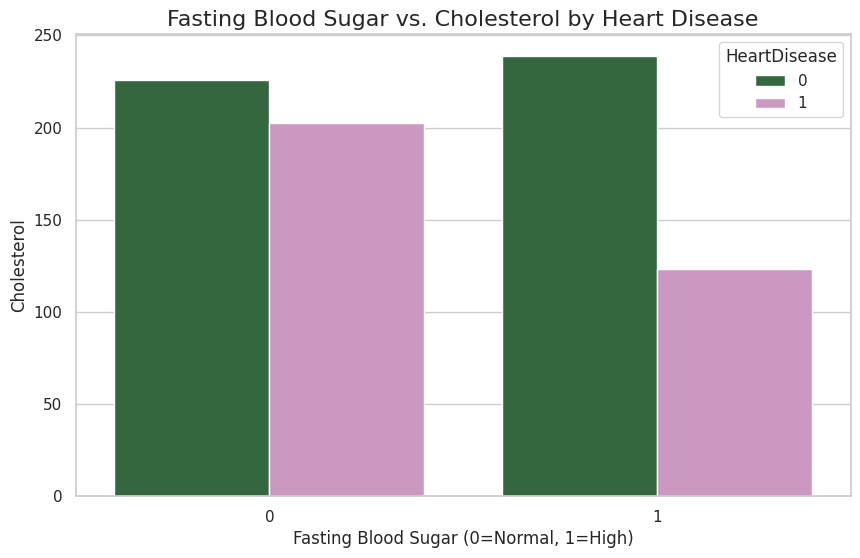

In [ ]:
# How Fasting Blood Sugar relate with Heart Disease?
# This bar plot illustrates the cholesterol levels across fasting blood sugar levels for individuals with and without heart disease.
plt.figure(figsize=(10, 6))
sns.barplot(data=data, x="FastingBS", y="Cholesterol", hue="HeartDisease", ci=None, palette="cubehelix")
plt.title("Fasting Blood Sugar vs. Cholesterol by Heart Disease", fontsize=16)
plt.xlabel("Fasting Blood Sugar (0=Normal, 1=High)", fontsize=12)
plt.ylabel("Cholesterol", fontsize=12)
plt.show()

Text(70.72222222222221, 0.5, 'ChestPainType')

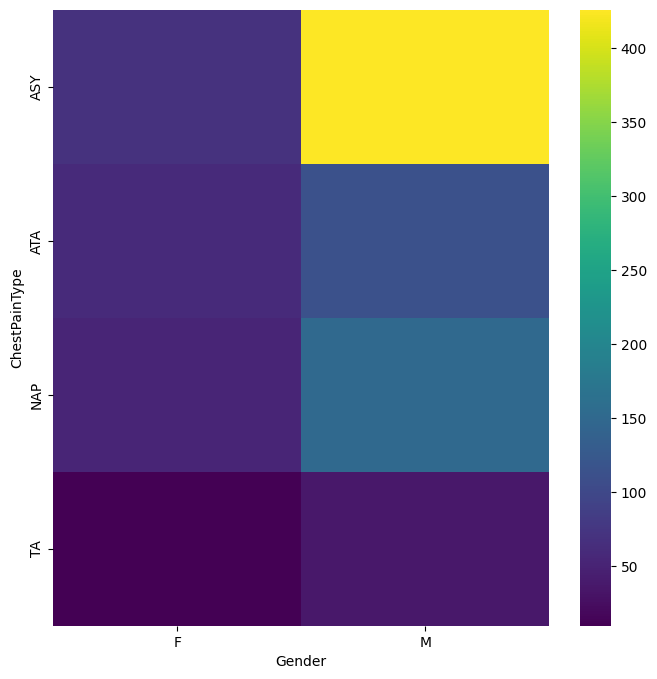

In [ ]:
#Gender vs ChestPainType
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['ChestPainType'].value_counts()
    for x_label, grp in data.groupby('Gender')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Gender')
plt.ylabel('ChestPainType')

Text(0, 0.5, 'Maximum Heart Rate')

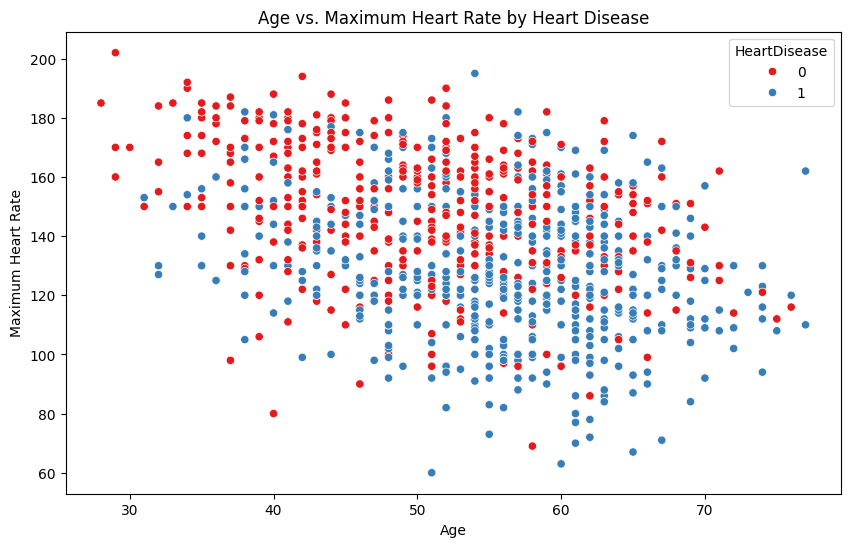

In [ ]:
#Age vs. Maximum Heart Rate by Heart Disease

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=data, palette='Set1')
plt.title('Age vs. Maximum Heart Rate by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')

#Conclusion:
The analysis of the heart disease detection dataset highlights significant factors that influence the likelihood of heart disease, such as age, cholesterol levels, blood pressure, and heart rate.
The study demonstrates that predictive models can be effectively used to identify individuals at high risk,
 enabling early intervention and better management of heart health.